In [64]:
import os
import cv2
import mlflow
import boto3
import warnings
import numpy as np 
import pandas as pd
import tensorflow as tf 
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import Counter
from PIL import Image
from tensorflow import keras

In [ ]:

warnings.filterwarnings("ignore")

Config={
    #"bucket_name":"plant-disease-models-vanshika",
    #"s3_data_path":"dataset",
    "local_data_dir":"../data",
    "epochs":25,
    "learning_rate":0.001,
    "batch_size":32,
    "seed":42,
    "image_width":224,
    "image_length":224,
    "model_name":"MobileNetV2",
    "optimizer":"Adam",
    "loss_function":"SparseCategoricalCrossentropy",
    "dataset":"PlantDoc"
}



In [66]:
TRAIN_DIR=os.path.join(
    Config["local_data_dir"],
    "train"
)
TEST_DIR=os.path.join(
    Config["local_data_dir"],
    "test"
)
IMG_SIZE=(
    Config["image_width"],
    Config["image_length"]
)
mlflow.end_run()
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment(
    "Plant_disease_mobileNet"
)

mlflow.start_run(
    run_name="baseline_preprocessing_pipeline"
)


<ActiveRun: >

In [67]:
mlflow.log_params(Config)

DATASET VISUALIZATION + CLEANING

In [68]:
train_classes = [
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
]
print(f"Total classes:{len(train_classes)}")
print(train_classes[:2])


Total classes:27
['Tomato leaf late blight', 'Potato leaf late blight']


CELL — IMAGE COUNT PER CLASS

In [69]:
class_counts={}
for class_name in train_classes:
    class_path=os.path.join(TRAIN_DIR,class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

class_df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Count": class_counts.values()
})

class_df = class_df.sort_values(
    by="Count",
    ascending=False
)

class_df.head()


,Class,Count
4,Corn leaf blight,179
24,Tomato Septoria leaf spot,140
19,Squash Powdery mildew leaf,124
7,Raspberry leaf,112
17,Potato leaf early blight,108


CELL — VISUALIZE DISTRIBUTION

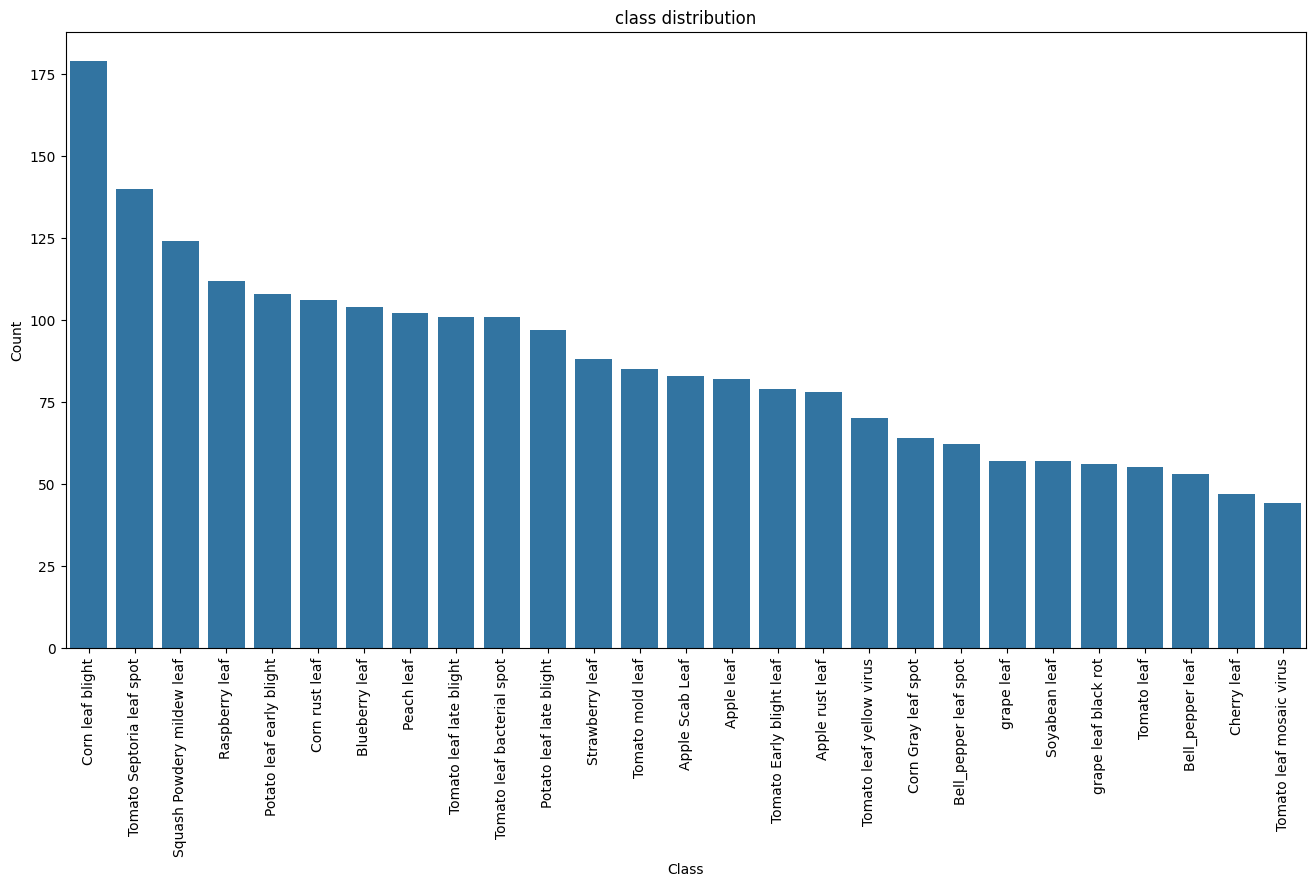

In [70]:
plt.figure(figsize=(16,8))

sns.barplot(
    x=class_df['Class'],
    y=class_df['Count']
)
plt.xticks(rotation=90)
plt.title("class distribution")
plt.show()

CELL — SAMPLE IMAGE VISUALIZATION

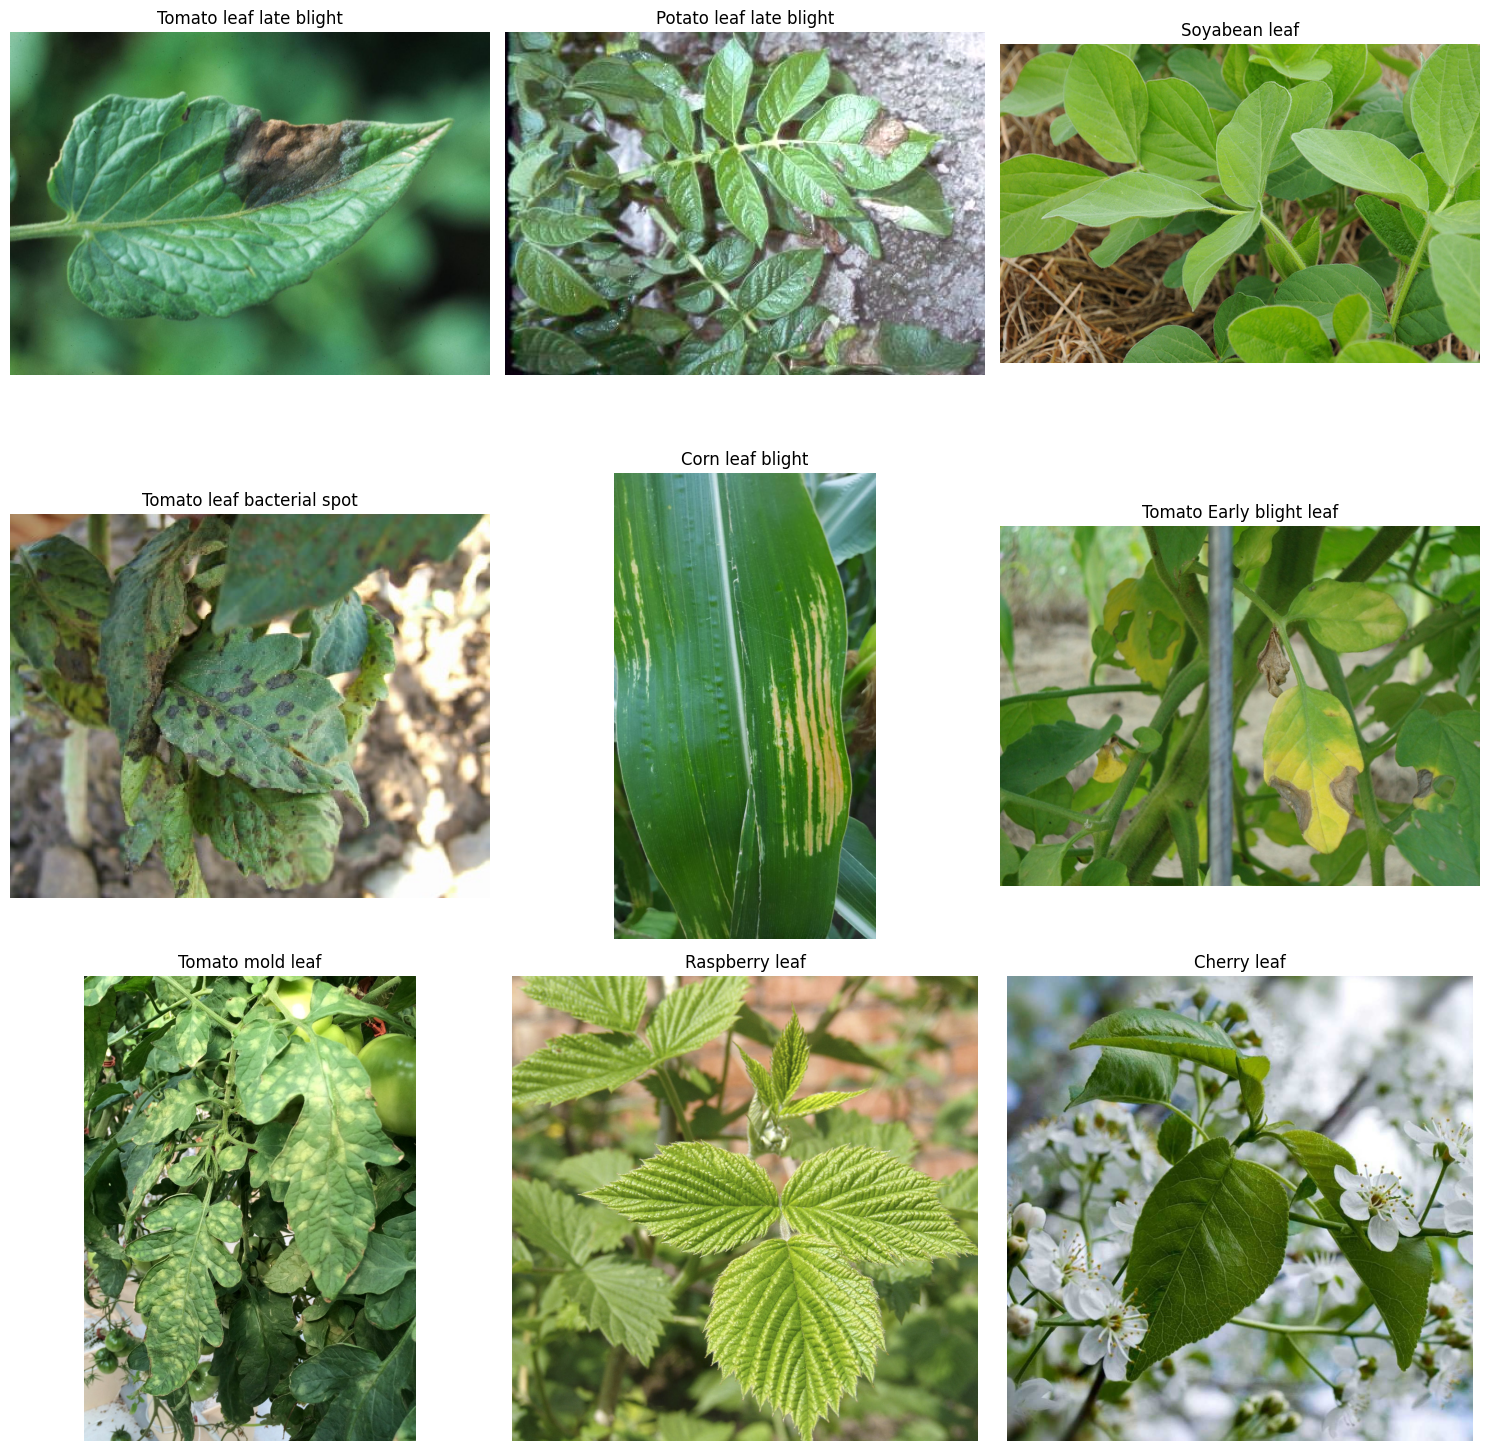

In [71]:
plt.figure(figsize=(15,15))

for idx, class_name in enumerate(train_classes[:9]):

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3,3,idx+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()
plt.show()

NOW IMPORTANT CLEANING STEP
CHECK CORRUPTED IMAGES

In [72]:
corrupted_images=[]

for class_name in train_classes:
    class_path=os.path.join(TRAIN_DIR,class_name)
    for image_file in os.listdir(class_path):
        image_path=os.path.join(class_path,image_file)
        try:
            img=cv2.imread(image_path)
            if img is None:
                corrupted_images.append(image_path)
        except:
            corrupted_images.append(image_path)
print("Corrupted Images:", len(corrupted_images))

Corrupted Images: 0


#REMOVE CORRUPTED FILES
TENSORFLOW PIPELINE
CELL — DATASET LOADING

In [73]:
train_classes = sorted([
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

test_classes = sorted([
    folder for folder in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, folder))
])

print("Train Classes:", len(train_classes))
print("Test Classes:", len(test_classes))

missing_in_test = set(train_classes) - set(test_classes)
missing_in_train = set(test_classes) - set(train_classes)

print("\nMissing in test:")
print(missing_in_test)

print("\nMissing in train:")
print(missing_in_train)

Train Classes: 27
Test Classes: 27

Missing in test:
set()

Missing in train:
set()


In [74]:
# import shutil

# shutil.rmtree("../data/train/Tomato two spotted spider mites leaf")

# print("Class removed successfully!")

In [75]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=Config["seed"],
    image_size=IMG_SIZE,
    batch_size=Config["batch_size"],
    shuffle=True
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=Config["seed"],
    image_size=IMG_SIZE,
    batch_size=Config["batch_size"],
    shuffle=True
)
test_dataset=tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=Config["batch_size"],
    shuffle=False
    #shuffle =falsse so seed doesnt matter here
)



Found 2334 files belonging to 27 classes.
Using 1868 files for training.
Found 2334 files belonging to 27 classes.
Using 466 files for validation.
Found 236 files belonging to 27 classes.


In [76]:
class_names = train_dataset.class_names

print(class_names)
print(f"Total Classes: {len(class_names)}")

['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'grape leaf', 'grape leaf black rot']
Total Classes: 27


NORMALIZATION

In [ ]:
#RGB integer values.
#0->255 to 0->1
#This alone can significantly improve performance because:
#MobileNetV2 expects:[-1,1]NOT:[0,1]
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
train_dataset=train_dataset.map(
    lambda x,y:(preprocess_input(x),y)
)

validation_dataset=validation_dataset.map(
    lambda x,y:(preprocess_input(x),y)
)

test_dataset=test_dataset.map(
    lambda x,y:(preprocess_input(x),y)
)

PREFETCHING

In [78]:


AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)
validation_dataset=validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [79]:
mlflow.log_param("num_classes", len(class_names))
mlflow.log_param("train_classes", class_names)
mlflow.log_metric("total_train_classes", len(class_names))

In [ ]:
data_augmentation=tf.keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
])
initial_learning_rate=Config['learning_rate']
lr_schedule=tf.keras.optimizers.schedules.ExponentialDecay(
          initial_learning_rate=initial_learning_rate,
          decay_steps=100,
          decay_rate=0.96,
          staircase=True

      )
base_model=tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE+(3,),
    include_top=False,
    weights="imagenet"

)
base_model.trainable=True
for layer in base_model.layers[:-30]:
    layer.trainable=False
model=tf.keras.Sequential([
data_augmentation,
base_model,
keras.layers.GlobalAveragePooling2D(),
keras.layers.BatchNormalization(),
keras.layers.Dropout(0.3),
keras.layers.Dense(len(class_names),activation='softmax')

])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.build(
    (None, Config["image_width"], Config["image_length"], 3)
)
callbacks=[
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

model.summary()

keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    to_file='model_visual.png'
)

model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=Config['epochs'],
    callbacks=callbacks
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ ?                      │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 646ms/step - accuracy: 0.0578 - loss: 3.8039 - val_accuracy: 0.0858 - val_loss: 3.2696
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 42s 705ms/step - accuracy: 0.1291 - loss: 3.1901 - val_accuracy: 0.1652 - val_loss: 2.9328
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 728ms/step - accuracy: 0.2003 - loss: 2.7647 - val_accuracy: 0.2318 - val_loss: 2.6841
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 657ms/step - accuracy: 0.2723 - loss: 2.4719 - val_accuracy: 0.2854 - val_loss: 2.5079
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 636ms/step - accuracy: 0.3314 - loss: 2.2288 - val_accuracy: 0.3262 - val_loss: 2.3801
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 607ms/step - accuracy: 0.4173 - loss: 2.0049 - val_accuracy: 0.3584 - val_loss: 2.2810
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 605ms/step - accuracy: 0.4279 - loss: 1.9133 - val_accuracy: 0.3734 - val_loss: 2.2049
Epoch 8/10
59/59 ━━━━━━━━━